# Thermal Emission Retrievals of Bare Rocky Exoplanets 

Tidally locked, hot, bare-rocky exoplanets provide a unique avenue to explore surface geology by probing mid-infrared absorption features characteristc of specific rocks.

In this tutorial, we explore how to perform retrieval analysis when assuming a bare rocky exoplanet with no atmosphere (though, we note that all the surface + atmosphere + clouds models featured in 'Reflecting and Emitting Surfaces' can be used in a retrieval. We only explore planetary bodies without atmospheres in this tutorial since, as we will see below, the retrieval run very fast compared to models with atmospheres and clouds). 

This tutorial assumes a basic understanding of the 'Atmospheric Retrievals with POSEIDON' tutorial. 

Lets define the stellar and planetary properties for our system: TOI 1685b. 

In [1]:
from POSEIDON.constants import R_Sun, R_J, M_J, R_E, M_E
from POSEIDON.core import create_star, create_planet, load_data, define_model, \
                          wl_grid_constant_R, set_priors, read_opacities
from POSEIDON.visuals import plot_data, plot_spectra_retrieved, plot_PT_retrieved
from POSEIDON.retrieval import run_retrieval
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, \
                             read_retrieved_log_X, plot_collection
from POSEIDON.corner import generate_cornerplot

import numpy as np
from scipy.constants import au
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.3     # Minimum wavelength (um)
wl_max = 15     # Maximum wavelength (um)
R = 1000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max,R)

#***** Define planet properties *****#

planet_name = 'TOI-1685b'  # Planet name used for plots, output files etc.

R_p = 1.468*R_E    # Planetary radius (m)
M_p = 3.03*M_E
d = 37.6153*pc
a_p = 0.01138*au

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, a_p = a_p)


#***** Define stellar properties *****#

R_s = 0.4555*R_Sun      # Stellar radius (m)
T_s = 3575        # Stellar effective temperature (K)
Met_s = 0.3          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] <--- note: for PHOENIX, only the solar metallicity models are used  
log_g_s = 4.778       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

## Loading Data 

Here, we have created a simulated JWST MIRI dataset with the online version of PANDEXO (https://exoctk.stsci.edu/pandexo/calculation/new) 

The online version of PANDEXO is a great alternative to the downloadable version featured in 

In order to make the spectrum, we 

1. Resolved the target 
2. Used the default stellar spectrum from phoenix 
3. Uploaded a forward model spectrum made in POSEIDON (micron, Fp/Fs) [we will keep the forward model here a secret, as to not ruin the suprise of the retrieval analysis]
4. Baseline of 1, and 10 transits 
5. MIRI LRS Spectroscopy, Slitless LRS, Optimize, 80% Full Well, and a Constant Minimum Noise of 0 

This process is a bit different than the one done in the 'Supporting a JWST Proposal with POSEIDON' tutorial. In particular, we are scattering simualted data around a spectrum that we then bin down, instead of using simulated error bars to generate synthetic data around. 

Lets load in our pandexo output! 

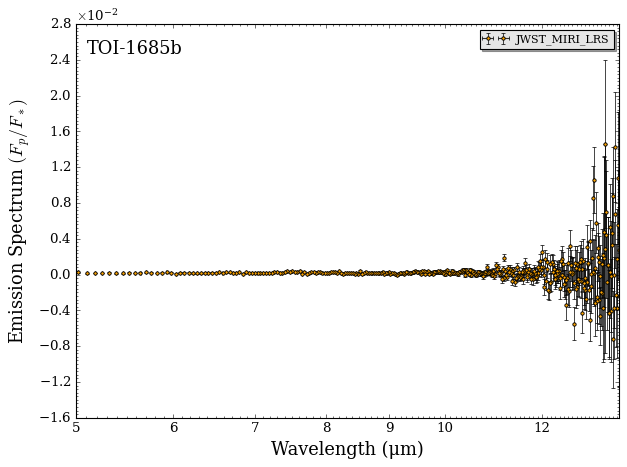

In [2]:
#***** Specify data location and instruments  *****#

data_dir = '../../../POSEIDON/reference_data/observations/TOI-1685b'         # Change this to where your data is stored
datasets = ['TOI-1685b-MIRI-PandexoOutput.txt']  # Found in reference_data/observations
instruments = ['JWST_MIRI_LRS']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl, skiprows = 1)

# Plot our data
fig_data = plot_data(data, planet_name, y_unit = 'eclipse_depth')

That looks very noisy. Lets go ahead and bin it down!

We have introduced a new function that takes pandexo output (scattered around a spectrum) and then bins it down. 

Since we often want to try many different binning resolutions, we also specify a 'saved_directory' to store the binned down data at. 

Note that, for MIRI data, you have to specify that it is MIRI since pandexo returns a txt file that is flipped in wavelength compared to other datasets. 

In [3]:
from POSEIDON.instrument import create_binned_down_data_from_pandexo

data_dir = '../../../POSEIDON/reference_data/observations/TOI-1685b'
saved_directory = data_dir + '/binned_spectra/'
file_name = 'TOI-1685b-MIRI-PandexoOutput.txt'  
R_to_bin = 15

create_binned_down_data_from_pandexo(file_name,
                            wl, R_to_bin,
                            stored_directory=data_dir, 
                            saved_directory = saved_directory, 
                            is_miri = True,)

Lets see what this dataset looks like

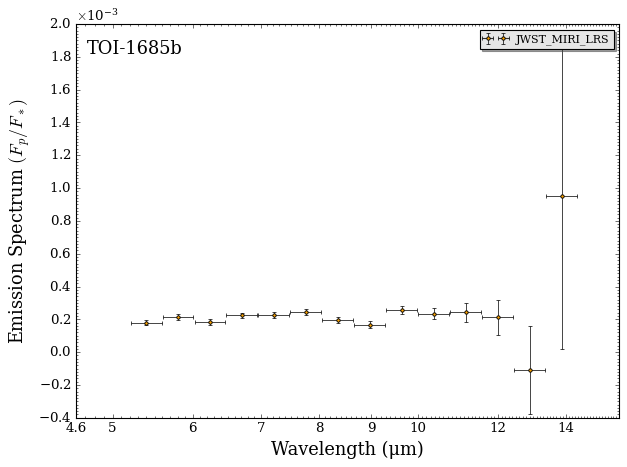

In [4]:
#***** Specify data location and instruments  *****#

data_dir = '../../../POSEIDON/reference_data/observations/TOI-1685b/binned_spectra'         # Change this to where your data is stored
datasets = ['TOI-1685b-MIRI-PandexoOutput_R15.txt']  # Found in reference_data/observations
instruments = ['JWST_MIRI_LRS']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl, skiprows = 1)

# Plot our data
fig_data = plot_data(data, planet_name, y_unit = 'eclipse_depth')

Since MIRI's sensitivity falls off extremely at the longest wavlenegths, lets zoom-in a bit 

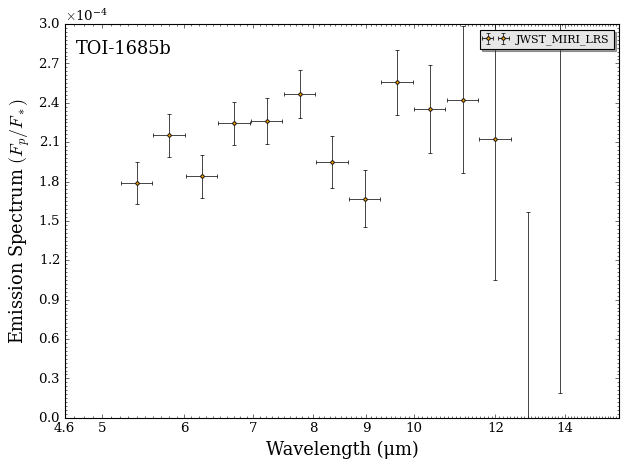

In [5]:
#***** Specify data location and instruments  *****#

data_dir = '../../../POSEIDON/reference_data/observations/TOI-1685b/binned_spectra'         # Change this to where your data is stored
datasets = ['TOI-1685b-MIRI-PandexoOutput_R15.txt']  # Found in reference_data/observations
instruments = ['JWST_MIRI_LRS']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl, skiprows = 1)

# Plot our data
fig_data = plot_data(data, planet_name, y_unit = 'eclipse_depth', y_min = 0, y_max = 3e-4)

Great! 

Now, lets set up our forward model. For bare rocks we are interested in two things: surface temperature, and surface composition.

For surface retrievals, lets try three different surface albedos simultaenously and see which the dataset favors the most. 

To do this, we define three surface components: 

1. Black = Albedo of 0 at all wavelengths. Would be synonymous with a non-detection of surface geology, but could help constrain a surface temperature. 

2. Granite = A felsic (silica-rich) rock. In the Solar System, only Earth has a large amount of granite when compared to other rocky planets due to plate tectonics (where mafic crust is reprocessed as granitic continental crust). However, granite by itelf doesn't always mean plate tectonics, as it could form due to a planet just being silica-rich from formation. 

3. Basalt = A mafic rock. In the Solar System, basalts represent the most ubiqituous surface, as it is the natural consequence of what forms from the partial melting of ultramafic mantle material. If this pattern extends beyond the Solar System, we would expect basalts to be common as an exoplanet surface. 

If you are more interested in how to start interpreting specific rocks in the context of exogeology, please check out Mullens et al (2026) Appendix material!

### CLR vs Uniform Priors 

Surface component percentages can be defined in both linear (0-1) and log space. For the retrievals in this tutorial, we'll demonstrate both for the uniform prior. 

Uniform priors are the normal, default prior, where percentages for each surface component are drawn seperatly and then normalized to 1. 

The CLR (Center-Log Ratio) Prior can also be utilized for surfaces. This prior is useful when you can't make any assumptions about which surface component will be the dominate surface component. In particular, this prior draws for N-1 surface component percentages, and fills the rest of the surface with the remaining surface component until they add up to 100%. In particular, it has less one less free parameter when compared to the uniform prior. Additionally, the CLR prior requires the percentages to be in log-space. 

In this tutorial, we will demonstrate both the uniform and the CLR prior. 

### Model Definitions

In [6]:
model_name_linear_uniform = 'TOI-1685b-Linear-Percentages'

#***** Define model *****#

bulk_species = []
param_species = []

# List the surface components here 
surface_components = ['Black','Granitoid_H12','Tholeiitic_basalt_H25']

# Create the model object
model_linear_uniform = define_model(model_name_linear_uniform, bulk_species, param_species, 
                            radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                            reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and thermal to True 
                            surface_model = 'lab_data',           # <----- Set surface_model to 'lab_data'
                            surface_components = surface_components,  # <----- Input surface_components                    
                            disable_atmosphere = True,                # <----- Set disable_atmosphere = True
                            surface_percentage_option = 'linear',     # <----- Use linear percentages (0 to 1)
                            surface_percentage_apply_to = 'models')    # <----- Apply percentages to models (3 models for each spectra)

print(model_linear_uniform['param_names'])

['R_p_ref' 'T_surf' 'Black_percentage' 'Granitoid_H12_percentage'
 'Tholeiitic_basalt_H25_percentage']


In [7]:
model_name_log_uniform = 'TOI-1685b-Log-Percentages-Uniform'

#***** Define model *****#

bulk_species = []
param_species = []

# List the surface components here 
surface_components = ['Black','Granitoid_H12','Tholeiitic_basalt_H25']

# Create the model object
model_log_uniform   = define_model(model_name_log_uniform, bulk_species, param_species, 
                            radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                            reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and thermal to True 
                            surface_model = 'lab_data',           # <----- Set surface_model to 'lab_data'
                            surface_components = surface_components,  # <----- Input surface_components                    
                            disable_atmosphere = True,                # <----- Set disable_atmosphere = True
                            surface_percentage_option = 'log',        # <----- Use log percentages
                            surface_percentage_apply_to = 'models')    # <----- Apply percentages to models (3 models for each spectra)

print(model_log_uniform['param_names'])

['R_p_ref' 'T_surf' 'log_Black_percentage' 'log_Granitoid_H12_percentage'
 'log_Tholeiitic_basalt_H25_percentage']


In [8]:
# Here we duplicate the model for the CLR prior

model_name_log_clr = 'TOI-1685b-Log-Percentages-CLR'

#***** Define model *****#

bulk_species = []
param_species = []

# List the surface components here 
surface_components = ['Black','Granitoid_H12','Tholeiitic_basalt_H25']

# Create the model object
model_log_clr   = define_model(model_name_log_clr, bulk_species, param_species, 
                            radius_unit = 'R_E', surface = True,  # <----- Set surface = True
                            reflection = True, thermal = True, thermal_scattering = True, # <----- Set reflection and thermal to True 
                            surface_model = 'lab_data',           # <----- Set surface_model to 'lab_data'
                            surface_components = surface_components,  # <----- Input surface_components                    
                            disable_atmosphere = True,                # <----- Set disable_atmosphere = True
                            surface_percentage_option = 'log',        # <----- Use log percentages
                            surface_percentage_apply_to = 'models')    # <----- Apply percentages to models (3 models for each spectra)

print(model_log_clr['param_names'])

['R_p_ref' 'T_surf' 'log_Black_percentage' 'log_Granitoid_H12_percentage'
 'log_Tholeiitic_basalt_H25_percentage']


## Uniform Prior, Linear Percentages

In [9]:
# Initialise prior type dictionary
prior_types = {}

# Specify uniform priors for all free parameters
prior_types['R_p_ref'] = 'uniform'
prior_types['T_surf'] = 'uniform'

prior_types['Black_percentage'] = 'uniform'
prior_types['Granitoid_H12_percentage'] = 'uniform'
prior_types['Tholeiitic_basalt_H25_percentage'] = 'uniform'

# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['R_p_ref'] = [0.9*R_p, 1.1*R_p]

prior_ranges['T_surf'] = [100,2000]

prior_ranges['Black_percentage'] = [0,1]
prior_ranges['Granitoid_H12_percentage'] = [0,1]
prior_ranges['Tholeiitic_basalt_H25_percentage'] = [0,1]

# Create prior object for retrieval
priors = set_priors(planet, star, model_linear_uniform, data, prior_types, prior_ranges)

Lets run the retrieval. 

Surface retrievals are very fast, since they do not need to compute atmospheric radiative transfer. 

In [10]:
#***** Specify fixed atmospheric settings for retrieval *****#

P = []
P_ref = []
opac = []

run_retrieval(planet, star, model_linear_uniform, opac, data, priors, wl, P, P_ref, R = R, 
                spectrum_type = 'emission', sampling_algorithm = 'MultiNest', 
                N_live = 500, verbose = True, resume = False)

POSEIDON now running 'TOI-1685b-Linear-Percentages'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  500
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.990991
Replacements:                                550
Total Samples:                               555
Nested Sampling ln(Z):               -500.042794
Acceptance Rate:                        0.980392
Replacements:                                600
Total Samples:                               612
Nested Sampling ln(Z):               -457.751338
Acceptance Rate:                        0.943396
Replacements:                                650
Total Samples:                               689
Nested Sampling ln(Z):               -380.846297
Acceptance Rate:                        

Lets go ahead and plot the results 

Note that for emission retrievals, POSEIDON saves Fp (not Fp/Fs), and therefore we must convert the retrieved spectra ourselves to Fp/Fs space. 

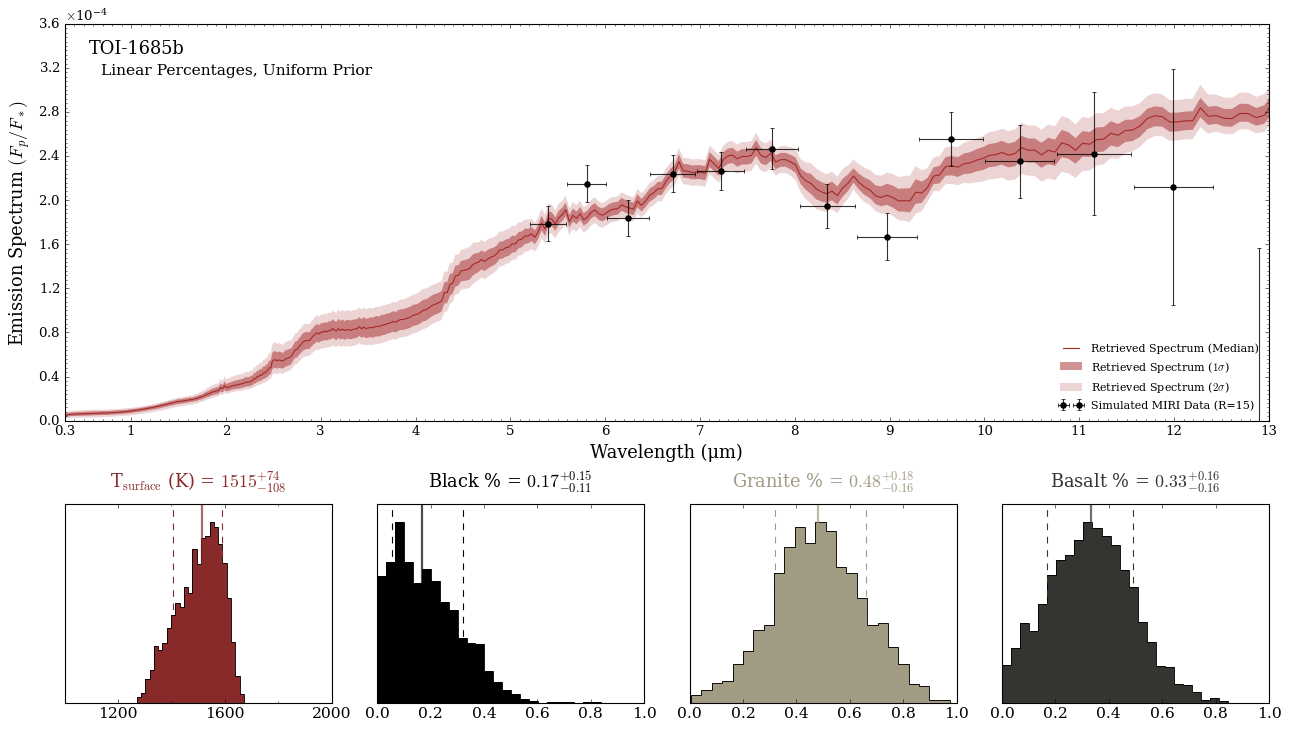

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [11]:
#***** Plotting magic *****#

import matplotlib.pyplot as plt
from POSEIDON.visuals import plot_histograms

fig_combined = plt.figure(constrained_layout=True, figsize=(16,9))    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AAAA
    AAAA
    abcd
    """
)

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name_linear_uniform)

# Convert to Fp/Fs 
d = 1        # This value only used for flux ratios, so it cancels

# Load stellar spectrum
F_s = star['F_star']
R_s = star['R_s']

# Convert stellar surface flux to observed flux at Earth
F_s_obs = (R_s / d)**2 * F_s

spec_low2 = spec_low2 / F_s_obs
spec_low1 = spec_low1 / F_s_obs
spec_median = spec_median / F_s_obs
spec_high1 = spec_high1 / F_s_obs
spec_high2 = spec_high2 / F_s_obs

# Plot
# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = []) 
spectra_low2 = plot_collection(spec_low2, wl, collection = []) 
spectra_high1 = plot_collection(spec_high1, wl, collection = []) 
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
ax_spectrum = axd['A']
_ = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                        spectra_high1, spectra_high2, planet_name,
                        data, R_to_bin = 150, show_ymodel = False,
                        colour_list = ['brown'], 
                        spectra_labels = ['Retrieved Spectrum'],
                        plt_label = 'Linear Percentages, Uniform Prior',
                        figure_shape = 'wide', save_fig = False,
                        ax = ax_spectrum,
                        sigma_to_plot = 2,
                        y_unit = 'eclipse_depth',
                        legend_location = 'lower right',
                        wl_axis = 'linear',
                        data_marker_size_list = [5],
                        data_colour_list = ['black'],
                        y_min = 0, y_max = 3.6e-4,
                        data_labels = ['Simulated MIRI Data (R=15)'],
                        wl_max = 13,
                        line_alpha_list = [1]
                        )

# Plot histograms 
axes_histograms = [axd["a"],axd["b"],axd["c"],axd["d"]]

models = [model_linear_uniform]

_ = plot_histograms(planet, models, plot_parameters = ['T_surf','Black_percentage',
                                                       'Granitoid_H12_percentage',
                                                       'Tholeiitic_basalt_H25_percentage'], 
                    span = ((1000,2000),(0,1),(0,1),(0,1)),
                    N_bins = [25,25,25,25],
                    parameter_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    axes = axes_histograms, save_fig = False,
                    tick_labelsize = 14,                          # x axis tick labels
                    title_fontsize = 16,                          # Title size
                    alpha_hist = [1,1,1,1],
                    title_alpha_list = [1,1,1,1],
                    custom_labels = ['T$_\mathrm{surface}$ (K)', 'Black %','Granite %','Basalt %'],
                    title_vert_spacing = 0.2,
                    title_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    )

It looks like we have some mid-infrared feature around 8-9 microns!

## Uniform Prior, Log Percentages

In [12]:
# Initialise prior type dictionary
prior_types = {}

# Specify uniform priors for all free parameters
prior_types['R_p_ref'] = 'uniform'
prior_types['T_surf'] = 'uniform'

prior_types['log_Black_percentage'] = 'uniform'
prior_types['log_Granitoid_H12_percentage'] = 'uniform'
prior_types['log_Tholeiitic_basalt_H25_percentage'] = 'uniform'

# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['R_p_ref'] = [0.9*R_p, 1.1*R_p]

prior_ranges['T_surf'] = [100,2000]

prior_ranges['log_Black_percentage'] = [-12,0]
prior_ranges['log_Granitoid_H12_percentage'] = [-12,0]
prior_ranges['log_Tholeiitic_basalt_H25_percentage'] = [-12,0]

# Create prior object for retrieval
priors = set_priors(planet, star, model_log_uniform, data, prior_types, prior_ranges)

In [13]:
#***** Specify fixed atmospheric settings for retrieval *****#

P = []
P_ref = []
opac = []

#***** Model wavelength grid *****#

wl_min = 0.3     # Minimum wavelength (um)
wl_max = 15     # Maximum wavelength (um)
R = 1000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max,R)

#***** Define stellar properties *****#

R_s = 0.4555*R_Sun      # Stellar radius (m)
T_s = 3575        # Stellar effective temperature (K)
Met_s = 0.3          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] <--- note: for PHOENIX, only the solar metallicity models are used  
log_g_s = 4.778       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

run_retrieval(planet, star, model_log_uniform, opac, data, priors, wl, P, P_ref, R = R, 
                spectrum_type = 'emission', sampling_algorithm = 'MultiNest', 
                N_live = 500, verbose = True, resume = False)

POSEIDON now running 'TOI-1685b-Log-Percentages-Uniform'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  500
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.994575
Replacements:                                550
Total Samples:                               553
Nested Sampling ln(Z):               -497.290081
Acceptance Rate:                        0.978793
Replacements:                                600
Total Samples:                               613
Nested Sampling ln(Z):               -464.367428
Acceptance Rate:                        0.948905
Replacements:                                650
Total Samples:                               685
Nested Sampling ln(Z):               -408.026753
Acceptance Rate:                   

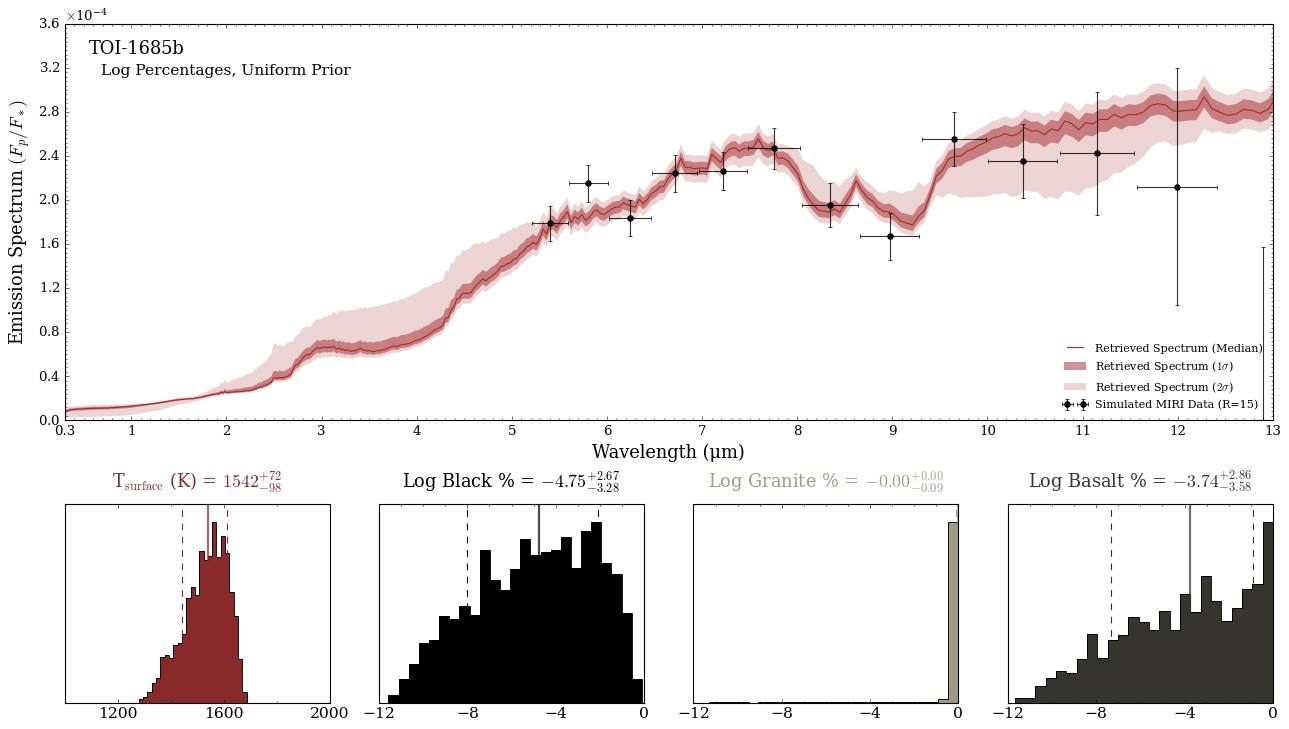

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [19]:
#***** Plotting magic *****#

import matplotlib.pyplot as plt
from POSEIDON.visuals import plot_histograms

fig_combined = plt.figure(constrained_layout=True, figsize=(16,9))    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AAAA
    AAAA
    abcd
    """
)

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name_log_uniform)

# Convert to Fp/Fs 
d = 1        # This value only used for flux ratios, so it cancels

# Load stellar spectrum
F_s = star['F_star']
R_s = star['R_s']

# Convert stellar surface flux to observed flux at Earth
F_s_obs = (R_s / d)**2 * F_s

spec_low2 = spec_low2 / F_s_obs
spec_low1 = spec_low1 / F_s_obs
spec_median = spec_median / F_s_obs
spec_high1 = spec_high1 / F_s_obs
spec_high2 = spec_high2 / F_s_obs

# Plot
# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = []) 
spectra_low2 = plot_collection(spec_low2, wl, collection = []) 
spectra_high1 = plot_collection(spec_high1, wl, collection = []) 
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
ax_spectrum = axd['A']
_ = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                        spectra_high1, spectra_high2, planet_name,
                        data, R_to_bin = 150, show_ymodel = False,
                        colour_list = ['brown'], 
                        spectra_labels = ['Retrieved Spectrum'],
                        plt_label = 'Log Percentages, Uniform Prior',
                        figure_shape = 'wide', save_fig = False,
                        ax = ax_spectrum,
                        sigma_to_plot = 2,
                        y_unit = 'eclipse_depth',
                        legend_location = 'lower right',
                        wl_axis = 'linear',
                        data_marker_size_list = [5],
                        data_colour_list = ['black'],
                        y_min = 0, y_max = 3.6e-4,
                        data_labels = ['Simulated MIRI Data (R=15)'],
                        wl_max = 13,
                        line_alpha_list = [1]
                        )

# Plot histograms 
axes_histograms = [axd["a"],axd["b"],axd["c"],axd["d"]]

models = [model_log_uniform]

_ = plot_histograms(planet, models, plot_parameters = ['T_surf','log_Black_percentage',
                                                       'log_Granitoid_H12_percentage',
                                                       'log_Tholeiitic_basalt_H25_percentage'], 
                    span = ((1000,2000),(-12,0),(-12,0),(-12,0)),
                    N_bins = [25,25,25,25],
                    parameter_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    axes = axes_histograms, save_fig = False,
                    tick_labelsize = 14,                          # x axis tick labels
                    title_fontsize = 16,                          # Title size
                    alpha_hist = [1,1,1,1],
                    title_alpha_list = [1,1,1,1],
                    custom_labels = ['T$_\mathrm{surface}$ (K)', 'Log Black %','Log Granite %','Log Basalt %'],
                    title_vert_spacing = 0.2,
                    title_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    )

In log space, it becomes a lot more obvious that what we are probing is granite. 

# CLR Prior, Log Percentages

Here, we set the prior type to 'CLR_surface'

The first surface component, 'black', will be the 'fill' surface (i.e., the non-free parameter that is added to granite + basalt to make the percentage 100%).

In [15]:
# Initialise prior type dictionary
prior_types = {}

# Specify uniform priors for all free parameters
prior_types['R_p_ref'] = 'uniform'
prior_types['T_surf'] = 'uniform'

prior_types['log_Black_percentage'] = 'CLR_surface'
prior_types['log_Granitoid_H12_percentage'] = 'CLR_surface'
prior_types['log_Tholeiitic_basalt_H25_percentage'] = 'CLR_surface'

# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['R_p_ref'] = [0.9*R_p, 1.1*R_p]

prior_ranges['T_surf'] = [100,2000]

prior_ranges['log_Black_percentage'] = [-12,0]
prior_ranges['log_Granitoid_H12_percentage'] = [-12,0]
prior_ranges['log_Tholeiitic_basalt_H25_percentage'] = [-12,0]

# Create prior object for retrieval
priors = set_priors(planet, star, model_log_clr, data, prior_types, prior_ranges)

In [16]:
#***** Specify fixed atmospheric settings for retrieval *****#

P = []
P_ref = []
opac = []

#***** Model wavelength grid *****#

wl_min = 0.3     # Minimum wavelength (um)
wl_max = 15     # Maximum wavelength (um)
R = 1000         # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max,R)

#***** Define stellar properties *****#

R_s = 0.4555*R_Sun      # Stellar radius (m)
T_s = 3575        # Stellar effective temperature (K)
Met_s = 0.3          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] <--- note: for PHOENIX, only the solar metallicity models are used  
log_g_s = 4.778       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

run_retrieval(planet, star, model_log_clr, opac, data, priors, wl, P, P_ref, R = R, 
                spectrum_type = 'emission', sampling_algorithm = 'MultiNest', 
                N_live = 500, verbose = True, resume = False)

POSEIDON now running 'TOI-1685b-Log-Percentages-CLR'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  500
 dimensionality =    5
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.998185
Replacements:                                550
Total Samples:                               551
Nested Sampling ln(Z):               -496.907870
Acceptance Rate:                        0.993377
Replacements:                                600
Total Samples:                               604
Nested Sampling ln(Z):               -473.018264
Acceptance Rate:                        0.977444
Replacements:                                650
Total Samples:                               665
Nested Sampling ln(Z):               -408.653354
Acceptance Rate:                       

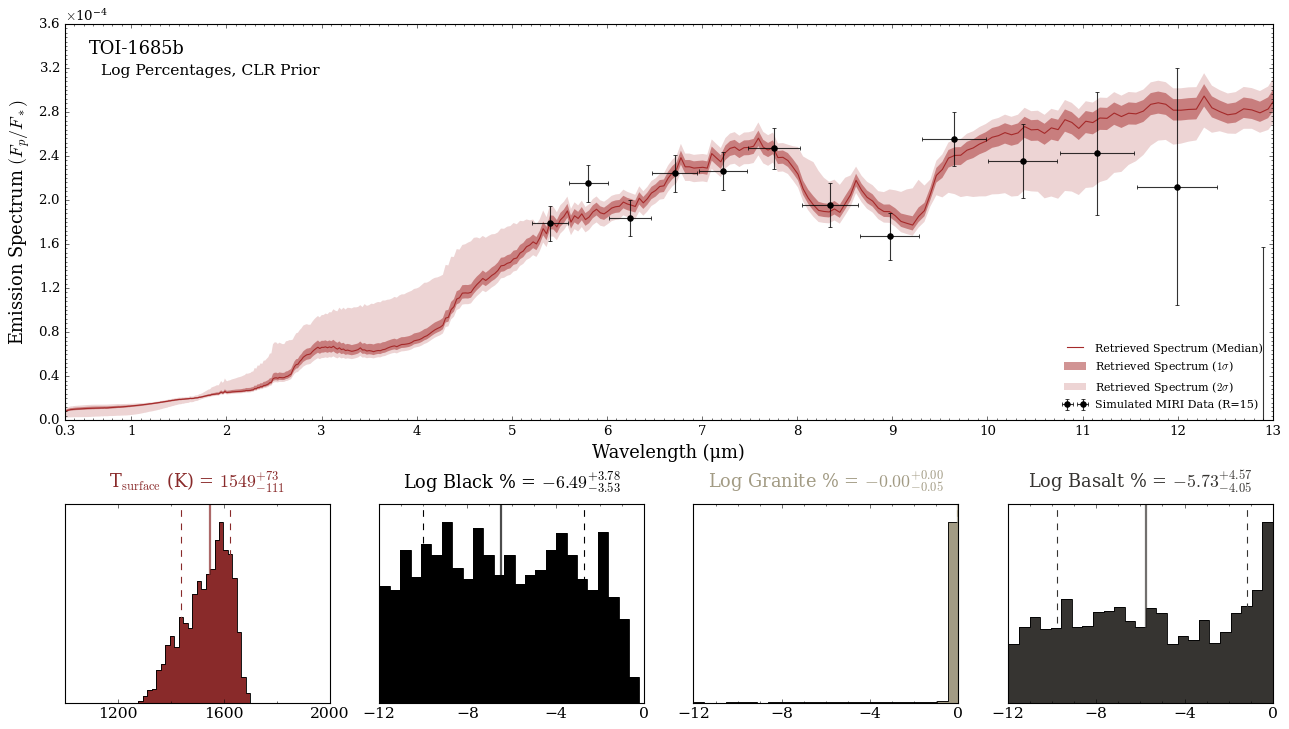

<Figure size 853.36x480 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [20]:
#***** Plotting magic *****#

import matplotlib.pyplot as plt
from POSEIDON.visuals import plot_histograms

fig_combined = plt.figure(constrained_layout=True, figsize=(16,9))    # Change (9,5.5) to alter the aspect ratio

# This function is the magic. Each letter corresponds to one matplotlib axis, which you can then pass to POSEIDON's plotting functions
axd = fig_combined.subplot_mosaic(
    """
    AAAA
    AAAA
    abcd
    """
)

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name_log_clr)

# Convert to Fp/Fs 
d = 1        # This value only used for flux ratios, so it cancels

# Load stellar spectrum
F_s = star['F_star']
R_s = star['R_s']

# Convert stellar surface flux to observed flux at Earth
F_s_obs = (R_s / d)**2 * F_s

spec_low2 = spec_low2 / F_s_obs
spec_low1 = spec_low1 / F_s_obs
spec_median = spec_median / F_s_obs
spec_high1 = spec_high1 / F_s_obs
spec_high2 = spec_high2 / F_s_obs

# Plot
# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = []) 
spectra_low2 = plot_collection(spec_low2, wl, collection = []) 
spectra_high1 = plot_collection(spec_high1, wl, collection = []) 
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
ax_spectrum = axd['A']
_ = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1, 
                        spectra_high1, spectra_high2, planet_name,
                        data, R_to_bin = 150, show_ymodel = False,
                        colour_list = ['brown'], 
                        spectra_labels = ['Retrieved Spectrum'],
                        plt_label = 'Log Percentages, CLR Prior',
                        figure_shape = 'wide', save_fig = False,
                        ax = ax_spectrum,
                        sigma_to_plot = 2,
                        y_unit = 'eclipse_depth',
                        legend_location = 'lower right',
                        wl_axis = 'linear',
                        data_marker_size_list = [5],
                        data_colour_list = ['black'],
                        y_min = 0, y_max = 3.6e-4,
                        data_labels = ['Simulated MIRI Data (R=15)'],
                        wl_max = 13,
                        line_alpha_list = [1]
                        )

# Plot histograms 
axes_histograms = [axd["a"],axd["b"],axd["c"],axd["d"]]

models = [model_log_clr]

_ = plot_histograms(planet, models, plot_parameters = ['T_surf','log_Black_percentage',
                                                       'log_Granitoid_H12_percentage',
                                                       'log_Tholeiitic_basalt_H25_percentage'], 
                    span = ((1000,2000),(-12,0),(-12,0),(-12,0)),
                    N_bins = [25,25,25,25],
                    parameter_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    axes = axes_histograms, save_fig = False,
                    tick_labelsize = 14,                          # x axis tick labels
                    title_fontsize = 16,                          # Title size
                    alpha_hist = [1,1,1,1],
                    title_alpha_list = [1,1,1,1],
                    custom_labels = ['T$_\mathrm{surface}$ (K)', 'Log Black %','Log Granite %','Log Basalt %'],
                    title_vert_spacing = 0.2,
                    title_colour_list = ["#892a2a",'black','#a29b84',"#363431"],
                    )

There we go! Looks like granite is the most likely surface component of this planet due to its strong feature at 8-9 microns (which is indicative of the mineral quartz), whereas basalt has a broader feature that is disfavored by the simualted data. Indeed, the data above was made from a forward model where granite was assumed to be 100% of the surface of this planet. 

From here-on, one can perform retrievals with just a single surface component and compare bayesian evidences to see if we are truly detecting a singular surface component, or one can explore what the absorption feature would look like if the planet's surface was a combination of 50% granite and 50% basalt.

If this was for a JWST proposal, once could explore adding on existing datasets (i.e., the recently published G395H eclipse dataset for this planet) to see if helps constrain the surface in conjunction with the MIRI data, or test whether or not you would need more MIRI transits to confidently detect granite, basalt, or a mix of the two. 

Either way, JWST provides the unique mid-infrared capability to begin explore exo-geology on exoplanet surfaces. 